[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mlnjsh/Introduction-to-Deep-Learning/blob/main/notebooks/Early_stopping_in_Neural_Networks_using_Keras.ipynb)

In [ ]:
# %tensorflow_version 1.x

# Steps to solve Emergency vs Non-Emergency vehicle classification problem using Early Stopping

<ol>1. Loading the dataset</ol>
<ol>2. Pre-processing the data</ol>
<ol>3. Creating training and validation set</ol>
<ol>4. Defining the model architecture</ol>
<ol>5. Compiling the model</ol>
<ol>6. Setting up Early Stopping</ol>
<ol>7. Training the model using Early Stopping</ol>
<ol>8. Evaluating model performance</ol>

## 1. Loading the dataset

In [1]:
# import necessary libraries and functions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# importing layers from keras
from keras.layers import Dense, InputLayer
from keras.models import Sequential
# importing adam optimizer from keras optimizer module
from keras.optimizers import Adam

# train_test_split to create training and validation set
from sklearn.model_selection import train_test_split
# accuracy_score to calculate the accuracy of predictions
from sklearn.metrics import accuracy_score

C:\Anaconda\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# reading the csv file
data = pd.read_csv('Dataset/emergency_classification.csv')

In [3]:
# create random number generator
seed = 42
rng = np.random.RandomState(seed)

In [4]:
# looking at first five rows of the data
data.head()

,image_names,emergency_or_not
0,0.jpg,1
1,1.jpg,1
2,2.jpg,1
3,3.jpg,1
4,4.jpg,1


In [5]:
# load images and store it in numpy array

# empty list to store the images
X = []
# iterating over each image
for img_name in data.image_names:
    # loading the image using its name
    img = plt.imread('Dataset/images/' + img_name)
    # saving each image in the list
    X.append(img)

# converting the list of images into array
X=np.array(X)

# storing the target variable in separate variable
y = data.emergency_or_not.values

In [6]:
# shape of the images
X.shape

(2352, 224, 224, 3)

## 2. Pre-processing the data

In [7]:
# converting 3 dimensional image to 1 dimensional image
X = X.reshape(X.shape[0], 224*224*3)
X.shape

(2352, 150528)

In [8]:
# minimum and maximum pixel values of images
X.min(), X.max()

(0, 255)

In [9]:
# normalizing the pixel values
X = X / X.max()

In [10]:
# minimum and maximum pixel values of images after normalizing
X.min(), X.max()

(0.0, 1.0)

## 3. Creating training and validation set

In [11]:
# creating a training and validation set
X_train, X_valid, y_train, y_valid=train_test_split(X,y,test_size=0.3, random_state=seed)

In [12]:
# shape of training and validation set
(X_train.shape, y_train.shape), (X_valid.shape, y_valid.shape)

(((1646, 150528), (1646,)), ((706, 150528), (706,)))

## 4. Defining the model architecture

In [13]:
# defining the model architecture
model=Sequential()

model.add(InputLayer(shape=(224*224*3,)))
model.add(Dense(100, activation='sigmoid'))
model.add(Dense(100, activation='sigmoid'))
model.add(Dense(units=1, activation='sigmoid'))

# Weights and Bias Initilized

## 5. Compiling the model

In [14]:
# defining the adam optimizer and setting the learning rate as 10^-5
adam = Adam(learning_rate=1e-5)

In [15]:
# compiling the model

# defining loss as binary crossentropy
# defining optimizer as Adam
# defining metrics as accuracy

model.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

## 6. Setting up Early Stopping

- In Keras, a **callback** is a set of functions or operations that are automatically executed during the training process of a model. Callbacks are especially useful for monitoring the training process, improving performance, or saving models, among other tasks. The keras.callbacks module provides a variety of predefined callbacks that can be used directly or customized.

### Purpose of Callbacks:
- Callbacks allow you to perform specific actions at certain stages of the model training process, such as:

- At the start or end of an epoch.
- At the start or end of a batch.
- After training is complete.
- Typical Use Cases of Callbacks:
- Monitoring and Adjusting Learning Rate: Adjusting the learning rate dynamically during training based on model performance.
- Stopping Early: Ending training when the model stops improving on a validation set (i.e., using EarlyStopping).
- Model Checkpoints: Saving the best model weights during training.
- Logging: Recording detailed information about the training process.
- TensorBoard: Logging performance metrics for visualization during training.

`EarlyStoping`
- Stops training early if the model performance on a validation set stops improving after a specified number of epochs.
``` python
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5)

```
```ModelCheckpoint```
- Saves the model (or just the weights) at regular intervals, often based on the validation performance. This is useful if you want to keep the model with the best validation performance.

```python
from keras.callbacks import ModelCheckpoint
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)
```
``` ReduceLROnPlateau```  
```python
from keras.callbacks import ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5)
```
- The ``factor`` parameter determines how much to reduce the learning rate by when the monitored metric (like validation loss) stops improving.
- The ``patience`` parameter determines how many epochs to wait before reducing the learning rate, after the monitored metric stops improving.

### TensorBoard:

Enables the use of **TensorBoard** to visualize metrics like loss, accuracy, learning rates, etc., in real-time.

**Example**:

```python
from keras.callbacks import TensorBoard
tensorboard = TensorBoard(log_dir='./logs')
```
### CSVLogger:

Logs training and validation metrics to a CSV file, making it easier to track the progress and analyze the results after training.

**Example**:

```python
from keras.callbacks import CSVLogger
csv_logger = CSVLogger('training_log.csv')

```
### LearningRateScheduler:

Dynamically adjusts the learning rate based on a predefined schedule.

**Example**:

```python
from keras.callbacks import LearningRateScheduler

def lr_schedule(epoch):
    return 0.001 * (0.1 ** int(epoch / 10))

lr_scheduler = LearningRateScheduler(lr_schedule)
```


In [37]:
# importing module for early stopping
from keras.callbacks import EarlyStopping

In [38]:
# setting up early stopping
early_stopping = EarlyStopping(monitor='val_loss', min_delta=0.01, patience=5, mode='min')
# min_delta -minimum change in the monitored metric to qualify as an improvement.
#If min_delta=0.01 and the validation loss improves from 0.30 to 0.29 (a change of 0.01), it will count as an improvement.
# mode ='min'-minimize the monitored metric

## 7. Training the model using Early Stopping

- total training images = 1646
- batch 128 
- 1 epoch = 1646/128 iterations 

### Iterations per epoch: 
$
\text{Iterations per epoch} = \frac{\text{Total training images}}{\text{Batch size}} 
= \frac{1646}{128} = 12.86 \approx 13
$


In [39]:
# training the model for 100 epochs

# defining the early stopping as callback using callbacks parameter of model.fit
model_history = model.fit(X_train, y_train, epochs=20, batch_size=128,validation_data=(X_valid,y_valid), callbacks=[early_stopping])

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 271ms/step - accuracy: 0.5802 - loss: 0.6786 - val_accuracy: 0.6572 - val_loss: 0.6555
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 211ms/step - accuracy: 0.6401 - loss: 0.6470 - val_accuracy: 0.6530 - val_loss: 0.6333
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 206ms/step - accuracy: 0.6718 - loss: 0.6260 - val_accuracy: 0.6388 - val_loss: 0.6310
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 207ms/step - accuracy: 0.6639 - loss: 0.6172 - val_accuracy: 0.6700 - val_loss: 0.6187
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 214ms/step - accuracy: 0.6902 - loss: 0.6022 - val_accuracy: 0.6898 - val_loss: 0.6079
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 212ms/step - accuracy: 0.7052 - loss: 0.6020 - val_accuracy: 0.6870 - val_loss: 0.6043
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 207ms/step - accuracy: 0.7009 - loss: 0.5973 - val_accuracy: 0.6615 - val_loss: 0.6082
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 206ms/step - accuracy: 0.7133 - loss: 0.5834 - val_accuracy: 0.

## 8. Evaluating model performance

In [40]:
y_pred = np.where(model.predict(X_valid)[:, 0] < 0.5, 0, 1)
y_pred

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


array([0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1,

In [41]:
# accuracy on validation set
print('Accuracy on validation set:', accuracy_score(y_valid, np.where(model.predict(X_valid)[:, 0] < 0.5, 0, 1)))

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Accuracy on validation set: 0.6912181303116147


In [42]:
# accuracy on validation set
print('Accuracy on validation set:', accuracy_score(y_valid, np.where(model.predict(X_valid)[:, 0] < 0.5, 0, 1)))

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Accuracy on validation set: 0.6912181303116147


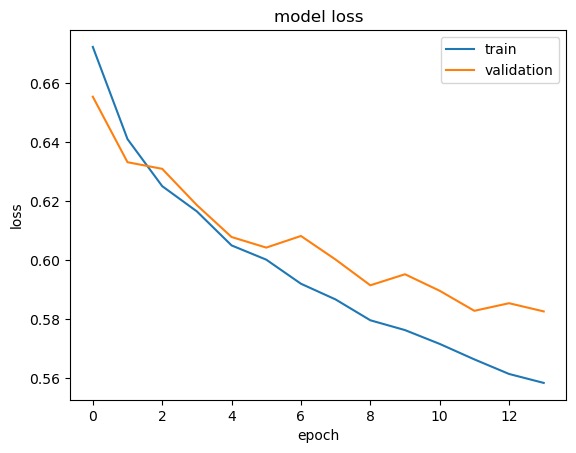

In [43]:
 # summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show()

# Check weights 

In [45]:
# Save weights after training
final_weights = model.get_weights()
#final_weights



## Hyperparameter tuning for Early Stopping (Increasing the patience value)

In [30]:
# defining and compiling the model

# defining the model architecture
model=Sequential()

model.add(InputLayer(shape=(224*224*3,)))
model.add(Dense(100, activation='sigmoid'))
model.add(Dense(100, activation='sigmoid'))
model.add(Dense(units=1, activation='sigmoid'))

# Define the optimizer after defining the model architecture
adam = Adam()


# compiling the model
model.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

In [31]:
# increasing the patience and threshold value
early_stopping = EarlyStopping(monitor='val_loss', min_delta=0.01, patience=10, mode='min')

- The model will stop training if the validation loss does not improve by at least 0.01 for 10 consecutive epochs.
- Otherwise, it will train for the full 30 epochs as specified.

In [32]:
# you guys train the model for 100 epochs
model_history = model.fit(X_train, y_train, epochs=30, batch_size=128,validation_data=(X_valid,y_valid), callbacks=[early_stopping])

Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 239ms/step - accuracy: 0.5505 - loss: 0.7334 - val_accuracy: 0.5609 - val_loss: 0.6918
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 201ms/step - accuracy: 0.5815 - loss: 0.6879 - val_accuracy: 0.5609 - val_loss: 0.6921
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 206ms/step - accuracy: 0.6067 - loss: 0.6728 - val_accuracy: 0.5609 - val_loss: 0.6860
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 199ms/step - accuracy: 0.5773 - loss: 0.6826 - val_accuracy: 0.5609 - val_loss: 0.6877
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 203ms/step - accuracy: 0.5828 - loss: 0.6810 - val_accuracy: 0.5609 - val_loss: 0.6874
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 204ms/step - accuracy: 0.5815 - loss: 0.6806 - val_accuracy: 0.5609 - val_loss: 0.6887
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 198ms/step - accuracy: 0.5741 - loss: 0.6837 - val_accuracy: 0.5609 - val_loss: 0.6877
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 198ms/step - accuracy: 0.5611 - loss: 0.6884 - val_accuracy: 0.

In [33]:
y_pred = model.predict(X_valid)[:,0]
y_pred = np.where(y_pred<0.5, 0, 1)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [34]:
# accuracy on validation set
y_pred = np.where(model.predict(X_valid)[:, 0] < 0.5, 0, 1)
print('Accuracy on validation set:', accuracy_score(y_valid, y_pred), '%')

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Accuracy on validation set: 0.5609065155807366 %


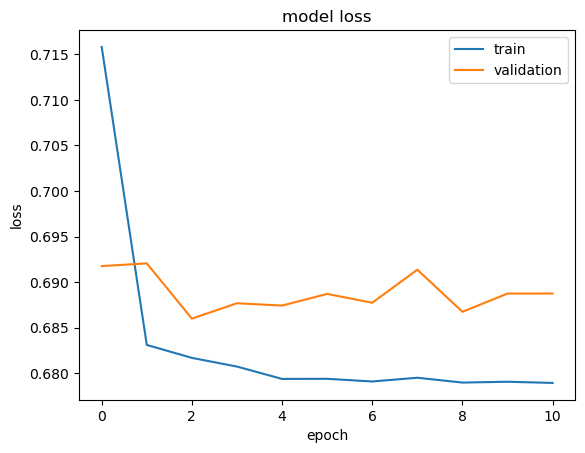

In [35]:
# summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show()

# Using Tensorboard

In [40]:
#!pip install tensorboard


# TensorBoard Tabs Explained

TensorBoard is a tool for monitoring and visualizing training processes in machine learning. Here's a step-by-step explanation of its main tabs.

---

## 1. Scalars Tab

This tab displays scalar metrics like loss and accuracy during training and validation.

### Key Features:
- Plots metrics such as `loss`, `val_loss`, `accuracy`, and `val_accuracy` over epochs or steps.
- Useful for tracking training progress and diagnosing overfitting or underfitting.

### How to Use:
1. Go to the **Scalars** tab.
2. Compare training and validation curves.
3. Identify trends such as:
   - Decreasing training loss.
   - Validation loss plateauing or increasing (indicating overfitting).

---

## 2. Graphs Tab

This tab shows the computational graph of your model.

### Key Features:
- Visualizes the structure of your neural network.
- Highlights data flow between layers (e.g., `Dense`, `Conv2D`).
- Useful for debugging and understanding model architecture.

### How to Use:
1. Navigate to the **Graphs** tab.
2. Inspect the model's layers and connections.
3. Verify input/output tensor dimensions.

---

## 3. Distributions Tab

This tab visualizes how weights and biases are distributed across layers over time.

### Key Features:
- Tracks the evolution of weights and biases during training.
- Helps identify issues such as vanishing or exploding gradients.

### How to Use:
1. Open the **Distributions** tab.
2. Check the spread of weights and biases for each layer.
3. Look for unexpected patterns, such as weights not updating or large oscillations.

---

## 4. Histograms Tab

This tab provides histograms of weights, biases, and activations for each layer.

### Key Features:
- Offers a deeper look at the distribution of values across layers.
- Useful for identifying anomalies like weights staying constant.

### How to Use:
1. Go to the **Histograms** tab.
2. Examine histograms of weights and biases for each layer.
3. Monitor how distributions shift over training epochs.

---

## 5. Projector Tab

This tab visualizes embeddings (e.g., word embeddings) using dimensionality reduction techniques like PCA or t-SNE.

### Key Features:
- Reduces high-dimensional data to 2D or 3D for visualization.
- Useful for analyzing the separation of classes or clusters in embeddings.

### How to Use:
1. Open the **Projector** tab.
2. Select an embedding layer or file if available.
3. Analyze clustering and relationships in the reduced space.

---

## 6. Images Tab (Optional)

This tab displays images logged during training, such as input images, feature maps, or predictions.

### Key Features:
- Visualizes how the model processes images.
- Useful for tasks like image segmentation or style transfer.

### How to Use:
1. Go to the **Images** tab.
2. View input images, predictions, or intermediate outputs.
3. Compare model output with ground truth.

---

## 7. Text Tab (Optional)

This tab displays text data logged during training, such as predictions, input sequences, or summaries.

### Key Features:
- Visualizes text data for NLP tasks like text classification or summarization.
- Helps analyze model performance on textual inputs.

### How to Use:
1. Navigate to the **Text** tab.
2. View logged text inputs, outputs, or evaluations.
3. Compare predictions to the ground truth.

---

## 8. Audio Tab (Optional)

This tab displays audio data logged during training, such as spectrograms or raw audio.

### Key Features:
- Visualizes audio for tasks like speech recognition or music generation.
- Helps monitor model outputs in audio-based tasks.

### How to Use:
1. Go to the **Audio** tab.
2. Play audio files to evaluate the model's outputs.

---

## 9. Hyperparameters Tab (Optional)

This tab visualizes the effect of hyperparameters on training metrics.

### Key Features:
- Tracks metrics across multiple training runs with different hyperparameter settings.
- Useful for hyperparameter tuning and optimization.

### How to Use:
1. Open the **Hyperparameters** tab.
2. Compare metrics for different hyperparameter configurations.
3. Identify the best-performing setup.

---

## 10. Time Series Tab (Optional)

This tab shows time-series data logged during training.

### Key Features:
- Monitors trends in real-time.
- Useful for streaming metrics like memory usage or custom metrics.

### How to Use:
1. Go to the **Time Series** tab.
2. Analyze trends over time.
3. Use this for debugging and optimizing runtime performance.

---

## Summary

TensorBoard provides a rich set of visualizations for monitoring training and debugging models. Use each tab according to your task to get insights into the training process.


In [16]:
from keras.callbacks import TensorBoard
tensorboard = TensorBoard(log_dir='./logs',histogram_freq=1)

In [17]:
model_history = model.fit(X_train, y_train, epochs=3, batch_size=128,validation_data=(X_valid,y_valid), callbacks=[tensorboard])

Epoch 1/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 989ms/step - accuracy: 0.5399 - loss: 0.6853 - val_accuracy: 0.6161 - val_loss: 0.6618
Epoch 2/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 357ms/step - accuracy: 0.6167 - loss: 0.6581 - val_accuracy: 0.6176 - val_loss: 0.6485
Epoch 3/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 340ms/step - accuracy: 0.6324 - loss: 0.6437 - val_accuracy: 0.6317 - val_loss: 0.6388


In [21]:
%reload_ext tensorboard

In [29]:
# Load TensorBoard notebook extension
%load_ext tensorboard

# Launch TensorBoard
%tensorboard --logdir ./logs
#%reload_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 15780), started 4:13:14 ago. (Use '!kill 15780' to kill it.)

In [23]:
!kill 15780

kill: 15780: No such process


In [26]:
from keras.callbacks import ModelCheckpoint
checkpoint = ModelCheckpoint(filepath='best_model.keras', monitor='val_loss', save_best_only=True)
model_history = model.fit(X_train, y_train, epochs=3, batch_size=128,validation_data=(X_valid,y_valid), callbacks=[checkpoint])

Epoch 1/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 449ms/step - accuracy: 0.6679 - loss: 0.6253 - val_accuracy: 0.6756 - val_loss: 0.6207
Epoch 2/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 267ms/step - accuracy: 0.6990 - loss: 0.6114 - val_accuracy: 0.6785 - val_loss: 0.6134
Epoch 3/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 259ms/step - accuracy: 0.7217 - loss: 0.5976 - val_accuracy: 0.6856 - val_loss: 0.6073


In [27]:
model.load_weights('best_model.keras')

In [28]:
model_history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_valid, y_valid),
    callbacks=[early_stopping, checkpoint, reduce_lr, tensorboard]
)


NameError: name 'early_stopping' is not defined